This notebook will test plotting an aerosol particle concentation profile derived from lidar measurements as documented in section 3.1 of [Ansmann et al 2023](https://doi.org/10.5194/acp-23-12821-2023).

In [2]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

In [4]:
# read example data file downloaded from PANGAEA
# https://doi.org/10.1594/PANGAEA.935539

# there is also ---20200417_0430-0508-267smooth.txt
# but I think this is lower vertical resolution
# (more smoothing)
filename = "/mnt/data/mosaic/polly-lidar/---20200417_0430-0508-61smooth.txt"

profile = pd.read_csv(
        filename,
        sep="\t",
        header=0,           # skip the original header line
        na_values=["NaN", "nan", ""],
        engine="python",
        encoding="latin-1",   # the mojibake ("h�he") suggests latin-1/cp1252 source;
                               # switch to "utf-8" if this errors on your system
    )
profile

,Height(km):,Beta355 (Mm^-1 sr^-1):,error beta355 (Mm^-1 sr^-1),Beta532 (Mm^-1 sr^-1):,error beta532 (Mm^-1 sr^-1),Beta1064 (Mm^-1 sr^-1):,error beta1064 (Mm^-1 sr^-1),alpha355 (Mm^-1 sr^-1):,error alpha355 (Mm^-1),alpha532 (Mm^-1 sr^-1):,...,error alpha355 NF (Mm^-1),Spar 355 NF (sr):,error Spar 355 NF (sr),BetaMOL 355 (m^-1 sr^-1),BetaMOL 532 (m^-1 sr^-1),BetaMOL 1064 (m^-1 sr^-1),Ang b355/532 NF,Error Ang b355/532 NF,Ang Ext NF,Error Ang Ext NF
0,0.227894,-6.426001,0.0,-1.102630,0.0,0.005240,0.0,-321.300073,0.0,-77.184090,...,0.0,NaN,0.0,0.009619,0.001805,0.000109,9.073010,NaN,8.241241,NaN
1,0.235365,-6.292666,0.0,-1.073887,0.0,0.008918,0.0,-314.633298,0.0,-75.172061,...,0.0,NaN,0.0,0.009612,0.001803,0.000109,12.609482,NaN,11.777713,NaN
2,0.242837,-6.156914,0.0,-1.044813,0.0,0.012696,0.0,-307.845687,0.0,-73.136900,...,0.0,NaN,0.0,0.009603,0.001802,0.000109,NaN,NaN,NaN,NaN
3,0.250308,-6.018887,0.0,-1.015033,0.0,0.016536,0.0,-300.944360,0.0,-71.052289,...,0.0,NaN,0.0,0.009599,0.001801,0.000109,NaN,NaN,NaN,NaN
4,0.257780,-5.879006,0.0,-0.984502,0.0,0.020434,0.0,-293.950305,0.0,-68.915115,...,0.0,NaN,0.0,0.009590,0.001799,0.000109,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2909,21.962372,1.173649,0.0,-0.020351,0.0,0.021991,0.0,58.682457,0.0,-1.424602,...,0.0,NaN,0.0,0.000348,0.000065,0.000004,NaN,NaN,NaN,NaN
2910,21.969843,1.803460,0.0,-0.046227,0.0,0.025034,0.0,90.172995,0.0,-3.235885,...,0.0,NaN,0.0,0.000347,0.000065,0.000004,NaN,NaN,NaN,NaN
2911,21.977315,1.621461,0.0,-0.020528,0.0,0.027147,0.0,81.073026,0.0,-1.436947,...,0.0,NaN,0.0,0.000347,0.000065,0.000004,NaN,NaN,NaN,NaN
2912,21.984786,1.568497,0.0,0.003116,0.0,0.028242,0.0,78.424835,0.0,0.218107,...,0.0,NaN,0.0,0.000346,0.000065,0.000004,NaN,NaN,NaN,NaN


In [5]:
# define conversion parameters from table 2
c65 = 12.5 # Mm cm-3



From paper section 4.2:
> The backscatter coefficients in Fig. 6 were multiplied by an extinction-to-backscatter ratio (lidar ratio) of 55 sr. The lidar ratio may vary between 40 and 70 sr; thus, the uncertainty in the extinction values is of the order of 25 %.

In [6]:
# define lidar ratio if I understood text of article well
L = 55 # sr

In [12]:
beta532 = profile["Beta532 (Mm^-1 sr^-1):"]
alpha532 = profile["alpha532 (Mm^-1 sr^-1):"]


From paper section 5.1:
> To minimize the impact of even weak fog events, we only considered lidar observations with a 532 nm backscatter coefficient of <1 Mm−1 sr−1 or extinction coefficients <55 Mm−1. Thus, after conversion of the extinction coefficients, only n50,dry values <700 cm−3 remained

In [18]:
flag = (beta532<1) & (alpha532<55)

In [19]:
n65 = c65 * L * beta532 * flag

In [20]:
n65

0      -758.058125
1      -738.297312
2      -718.308937
3      -697.835188
4      -676.845125
           ...    
2909    -13.991313
2910    -31.781062
2911    -14.113000
2912      2.142250
2913      6.476938
Length: 2914, dtype: float64

(0.0, 10.0)

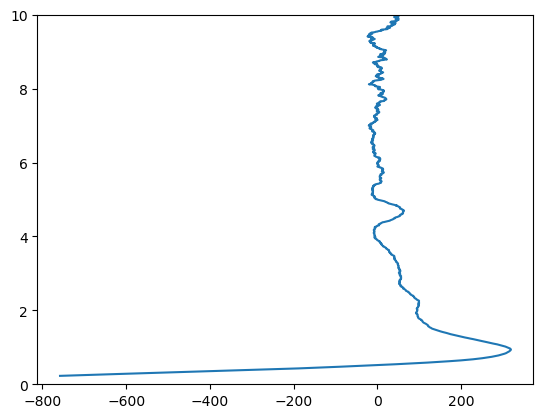

In [24]:
plt.plot(n65, profile["Height(km):"])
plt.ylim(0,10)

In [29]:
def n_from_backscatter(beta, c, l, flag):
    return(beta*c*l*flag)

In [30]:
c65_lo, c65_hi = 11.2, 15
n65_lo = n_from_backscatter(beta532, c65_lo, L, flag)
n65_hi = n_from_backscatter(beta532, c65_hi, L, flag)

(0.0, 448.10002875)

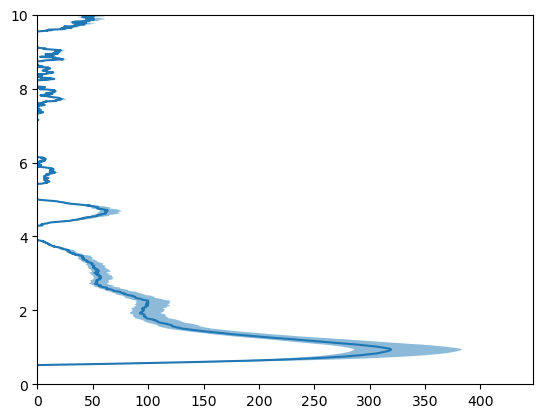

In [34]:
plt.plot(n65, profile["Height(km):"])
plt.ylim(0,10)

plt.fill_betweenx(profile["Height(km):"], n65_lo, n65_hi, alpha=0.5)
plt.xlim(left=0)


In [35]:
c85_lo, c85, c85_hi = 9.6, 10, 12.2
n85 = n_from_backscatter(beta532, c85, L, flag)
n85_lo = n_from_backscatter(beta532, c85_lo, L, flag)
n85_hi = n_from_backscatter(beta532, c85_hi, L, flag)

(0.0, 448.10002875)

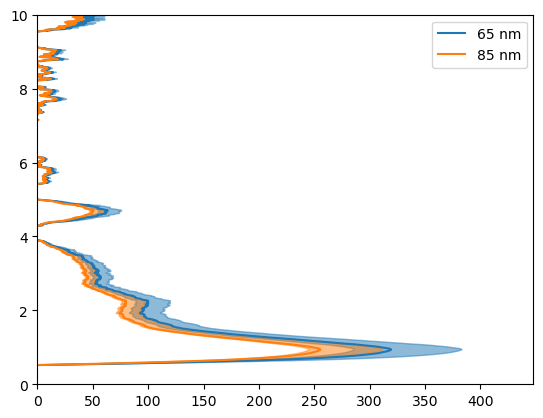

In [36]:
l65, = plt.plot(n65, profile["Height(km):"], label="65 nm")
l85, = plt.plot(n85, profile["Height(km):"], label="85 nm")
plt.legend()
plt.ylim(0,10)

plt.fill_betweenx(profile["Height(km):"], n65_lo, n65_hi, color=l65.get_color(), alpha=0.5)
plt.fill_betweenx(profile["Height(km):"], n85_lo, n85_hi, color=l85.get_color(), alpha=0.5)
plt.xlim(left=0)


In [37]:
c250_lo, c250, c250_hi = 0.22, 0.25, 0.28
n250 = n_from_backscatter(beta532, c250, L, flag)
n250_lo = n_from_backscatter(beta532, c250_lo, L, flag)
n250_hi = n_from_backscatter(beta532, c250_hi, L, flag)

c290_lo, c290, c290_hi = 0.12, 0.13, 0.145
n290 = n_from_backscatter(beta532, c290, L, flag)
n290_lo = n_from_backscatter(beta532, c290_lo, L, flag)
n290_hi = n_from_backscatter(beta532, c290_hi, L, flag)


(0.0, 448.10002875)

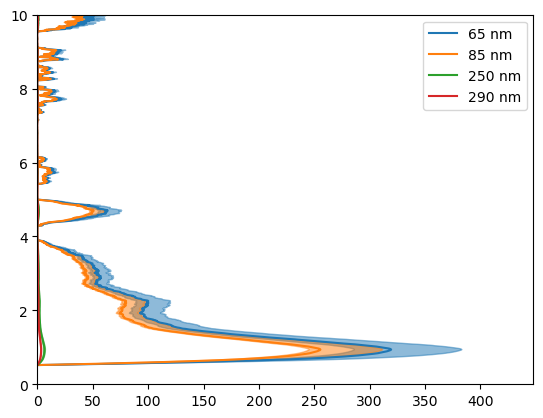

In [38]:
l65, = plt.plot(n65, profile["Height(km):"], label="65 nm")
l85, = plt.plot(n85, profile["Height(km):"], label="85 nm")
l250, = plt.plot(n250, profile["Height(km):"], label="250 nm")
l290, = plt.plot(n290, profile["Height(km):"], label="290 nm")
plt.legend()
plt.ylim(0,10)

plt.fill_betweenx(profile["Height(km):"], n65_lo, n65_hi, color=l65.get_color(), alpha=0.5)
plt.fill_betweenx(profile["Height(km):"], n85_lo, n85_hi, color=l85.get_color(), alpha=0.5)
plt.fill_betweenx(profile["Height(km):"], n250_lo, n250_hi, color=l250.get_color(), alpha=0.5)
plt.fill_betweenx(profile["Height(km):"], n290_lo, n290_hi, color=l290.get_color(), alpha=0.5)
plt.xlim(left=0)


# Conclusion

This seems to produce reasonable numbers although clearly there are plenty of ways I could be doing this wrong.

Next step would be to write functions for the calculation of the profile of a given size (including high/low values based on the conversion factor range) and then put of all of it into a function that can process all the profiles from a given data file, so that I can do multiple times.